# Pregunta 8: Mapas de tendencia (con significancia) de métricas de duración de dry spells en ALADIN

## Objetivo
Calcular **tendencias lineales** (días/década) en **ALADIN histórico** para distintas métricas de duración de **dry spells** y mapear:

- **Pendiente** (días/década)
- **Significancia estadística** (hachurado donde \(p < 0.05\))

## Definiciones (consistentes con Opción B)
- **Día seco (ALADIN):** `pr < 5.285 mm/día` (\(\tau^*\) de Pregunta 6 para referencia CR2MET=1 mm)
- **Dry spell:** racha consecutiva de días secos

## Dominio y periodo
- **Chile continental** (Natural Earth `admin_0_countries`, 10m)
- Grilla: **ALADIN CHP12** (curvilínea `y`×`x`, `lat/lon` 2D)
- Periodo: **1980–2014** (histórico común usado en Preguntas 6–7)

## Métricas anuales por píxel
Para cada año se construye la lista de duraciones de dry spells y se calculan:
- `mean`: duración media (días)
- `t99`: percentil 99 de duración (días)
- `n_spells`: número de rachas (para control de calidad)

Luego se ajusta una regresión lineal en el tiempo para cada píxel y métrica.

In [12]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from pathlib import Path
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.shapereader as shpreader
from shapely.geometry import Point
from shapely.ops import unary_union
from shapely.prepared import prep
from scipy import stats
from IPython.display import display

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.grid'] = False

# =====================================================================
# CONFIG
# =====================================================================
START_DATE = '1980-01-01'
END_DATE = '2014-12-31'
ALPHA = 0.05
MIN_YEARS_TREND = 30  # años mínimos para trend por pixel

# Opción B
DRY_THRESHOLD_ALADIN = 5.285  # mm/día

DOMAIN_MASK_RESOLUTION = '10m'
CHILE_EXTENT = [-76, -65, -55, -17]

# Métricas
MIN_SPELLS_FOR_STATS = 20  # mínimo de rachas para estimar mean/t99 en un año
METRICS = ['mean', 't99', 'n_spells']

print('Config:', START_DATE, END_DATE, '| dry(ALADIN)<', DRY_THRESHOLD_ALADIN, '| alpha=', ALPHA)


Config: 1980-01-01 2014-12-31 | dry(ALADIN)< 5.285 | alpha= 0.05


In [13]:
# =====================================================================
# DOMINIO (Chile) SOBRE GRILLA ALADIN
# =====================================================================
def load_chile_geometry():
    shp_path = shpreader.natural_earth(
        resolution=DOMAIN_MASK_RESOLUTION,
        category='cultural',
        name='admin_0_countries',
    )
    reader = shpreader.Reader(shp_path)
    geoms = [
        record.geometry
        for record in reader.records()
        if record.attributes.get('NAME') == 'Chile' or record.attributes.get('ADMIN') == 'Chile'
    ]
    if not geoms:
        raise RuntimeError('No se encontro Chile en Natural Earth admin_0_countries')
    return unary_union(geoms)


def build_chile_mask_on_aladin_grid(lat2d, lon2d, geometry):
    prepared = prep(geometry)
    flat_mask = np.fromiter(
        (
            prepared.contains(Point(float(x), float(y))) or geometry.touches(Point(float(x), float(y)))
            for y, x in zip(lat2d.ravel(), lon2d.ravel())
        ),
        dtype=bool,
        count=lat2d.size,
    )
    return flat_mask.reshape(lat2d.shape)


def open_aladin_historical():
    files = sorted(Path('pr1').glob('pr_CHP12_*_historical_*.nc'))
    if not files:
        raise FileNotFoundError('No se encontraron archivos ALADIN en ./pr1/')
    ds = xr.open_mfdataset([str(p) for p in files], use_cftime=True, chunks={'time': 365})
    # kg m-2 s-1 -> mm/día
    return ds['pr'].sel(time=slice(START_DATE, END_DATE)) * 86400.0


print('1/4: Cargando ALADIN histórico y máscara Chile...')
pr_aladin = open_aladin_historical()
chile_geom = load_chile_geometry()
chile_mask_bool = build_chile_mask_on_aladin_grid(pr_aladin['lat'].values, pr_aladin['lon'].values, chile_geom)
chile_mask = xr.DataArray(
    chile_mask_bool,
    coords={'y': pr_aladin['y'], 'x': pr_aladin['x'], 'lat': pr_aladin['lat'], 'lon': pr_aladin['lon']},
    dims=['y', 'x'],
    name='chile_mask',
)

pr_aladin_chile = pr_aladin.where(chile_mask)

# ALADIN usa cftime; usamos accessor .dt (compatibles con cftime)
years = np.unique(pr_aladin_chile['time'].dt.year.values.astype(int))
years = years[(years >= int(START_DATE[:4])) & (years <= int(END_DATE[:4]))]
print('Años:', int(years[0]), '-', int(years[-1]), '| n=', len(years))
print('Celdas Chile:', int(chile_mask.sum().values))


1/4: Cargando ALADIN histórico y máscara Chile...
Años: 1980 - 2014 | n= 35
Celdas Chile: 3587


In [14]:
# =====================================================================
# DRY SPELLS POR AÑO (por píxel)
# =====================================================================
def run_lengths_1d(bool_series):
    x = np.asarray(bool_series, dtype=np.bool_)
    if x.size == 0:
        return np.array([], dtype=np.int16)
    padded = np.r_[False, x, False]
    dx = np.diff(padded.astype(np.int8))
    starts = np.where(dx == 1)[0]
    ends = np.where(dx == -1)[0]
    return (ends - starts).astype(np.int16)


def annual_metrics_from_durations(durations, min_spells=MIN_SPELLS_FOR_STATS):
    d = np.asarray(durations, dtype=float)
    d = d[np.isfinite(d) & (d > 0)]
    n = int(d.size)
    if n < min_spells:
        return {'mean': np.nan, 't99': np.nan, 'n_spells': n}
    return {
        'mean': float(np.mean(d)),
        't99': float(np.percentile(d, 99)),
        'n_spells': n,
    }


def build_aladin_annual_metric_cube(pr_masked, dry_threshold, mask_da, years_list):
    """Devuelve DataArray (year, metric, y, x) con métricas anuales de duración de rachas."""
    # cftime-safe
    year_arr = pr_masked['time'].dt.year.values.astype(np.int32)
    years_list = np.asarray(years_list, dtype=np.int32)

    # booleano seco y stack a (time, cell)
    is_dry = (pr_masked < dry_threshold).where(mask_da)
    dry_stacked = is_dry.stack(cell=('y', 'x')).transpose('time', 'cell').compute()
    dry_vals = dry_stacked.values

    # Convertir a bool seguro: NaN -> False para no generar rachas espurias
    dry_bool = np.isfinite(dry_vals) & (dry_vals.astype(bool))

    out = np.full((len(years_list), len(METRICS), dry_bool.shape[1]), np.nan, dtype=np.float32)
    # n_spells como float en el cubo (se puede castear después)

    year_to_idx = {int(y): i for i, y in enumerate(years_list)}

    # índices por año para rebanar rápido
    year_slices = {}
    for y in years_list:
        idx = np.where(year_arr == int(y))[0]
        year_slices[int(y)] = idx

    for cell_idx in range(dry_bool.shape[1]):
        col = dry_bool[:, cell_idx]
        if not np.any(col):
            continue
        for y in years_list:
            idx = year_slices[int(y)]
            if idx.size == 0:
                continue
            durs = run_lengths_1d(col[idx])
            m = annual_metrics_from_durations(durs)
            yi = year_to_idx[int(y)]
            out[yi, 0, cell_idx] = m['mean']
            out[yi, 1, cell_idx] = m['t99']
            out[yi, 2, cell_idx] = float(m['n_spells'])

    # unstack a (year, metric, y, x)
    da = xr.DataArray(
        out,
        coords={
            'year': years_list,
            'metric': METRICS,
            'cell': dry_stacked['cell'],
        },
        dims=('year', 'metric', 'cell'),
    ).unstack('cell')
    da = da.assign_coords(lat=mask_da['lat'], lon=mask_da['lon'])
    return da


print('2/4: Construyendo cubo anual (ALADIN) de métricas de duración... (puede tardar)')
annual_cube = build_aladin_annual_metric_cube(pr_aladin_chile, DRY_THRESHOLD_ALADIN, chile_mask, years)
annual_cube


2/4: Construyendo cubo anual (ALADIN) de métricas de duración... (puede tardar)


<xarray.DataArray (year: 35, metric: 3, y: 255, x: 68)> Size: 7MB
array([[[[       nan,  2.8245614,  2.8095238, ...,        nan,
                 nan,        nan],
         [       nan,        nan,        nan, ...,        nan,
                 nan,        nan],
         [       nan,  2.7818182,        nan, ...,        nan,
                 nan,        nan],
         ...,
         [       nan,        nan,        nan, ...,        nan,
                 nan,        nan],
         [       nan,        nan,        nan, ...,        nan,
                 nan,        nan],
         [       nan,        nan,        nan, ...,        nan,
                 nan,        nan]],

        [[       nan, 13.32     , 13.14     , ...,        nan,
                 nan,        nan],
         [       nan,        nan,        nan, ...,        nan,
                 nan,        nan],
         [       nan, 13.38     ,        nan, ...,        nan,
                 nan,        nan],
...
                 nan,        nan],
         [       nan,        nan,        nan, ...,        nan,
                 nan,        nan],
         [       nan,        nan,        nan, ...,        nan,
                 nan,        nan]],

        [[       nan, 46.       , 48.       , ...,        nan,
                 nan,        nan],
         [       nan,        nan,        nan, ...,        nan,
                 nan,        nan],
         [       nan, 47.       ,        nan, ...,        nan,
                 nan,        nan],
         ...,
         [       nan,        nan,        nan, ...,        nan,
                 nan,        nan],
         [       nan,        nan,        nan, ...,        nan,
                 nan,        nan],
         [       nan,        nan,        nan, ...,        nan,
                 nan,        nan]]]],
      shape=(35, 3, 255, 68), dtype=float32)
Coordinates:
  * year     (year) int32 140B 1980 1981 1982 1983 1984 ... 2011 2012 2013 2014
  * metric   (metric) <U8 96B 'mean' 't99' 'n_spells'
  * y        (y) int64 2kB 0 1 2 3 4 5 6 7 8 ... 247 248 249 250 251 252 253 254
  * x        (x) int64 544B 0 1 2 3 4 5 6 7 8 9 ... 59 60 61 62 63 64 65 66 67
    lat      (y, x) float64 139kB dask.array<chunksize=(255, 68), meta=np.ndarray>
    lon      (y, x) float64 139kB dask.array<chunksize=(255, 68), meta=np.ndarray>

In [15]:
# =====================================================================
# TENDENCIA LINEAL VECTORIZADA + P-VALUE (como pregunta4.ipynb)
# =====================================================================
def vectorized_linear_trend(annual_da):
    """annual_da: (year, y, x) -> slope (dias/decada) y p_value."""
    da = annual_da.compute()
    years_f = da['year'].values.astype(float)
    values = da.values

    n_time = values.shape[0]
    flat = values.reshape(n_time, -1)
    valid = np.all(np.isfinite(flat), axis=0)

    x = years_f
    x_mean = x.mean()
    x_anom = x - x_mean
    ssx = np.sum(x_anom ** 2)

    slope = np.full(flat.shape[1], np.nan)
    p_value = np.full(flat.shape[1], np.nan)

    y = flat[:, valid]
    y_mean = y.mean(axis=0)
    y_anom = y - y_mean
    ssy = np.sum(y_anom ** 2, axis=0)
    cov = np.sum(x_anom[:, None] * y_anom, axis=0)

    slope_valid = cov / ssx
    denom = np.sqrt(ssx * ssy)
    r = np.divide(cov, denom, out=np.zeros_like(cov), where=denom > 0)
    r = np.clip(r, -0.999999, 0.999999)

    dfree = len(x) - 2
    t_stat = np.abs(r) * np.sqrt(dfree / np.maximum(1e-12, 1.0 - r ** 2))
    p_valid = 2.0 * stats.t.sf(t_stat, dfree)

    zero_var = ssy <= 0
    slope_valid[zero_var] = np.nan
    p_valid[zero_var] = np.nan

    slope[valid] = slope_valid * 10.0  # per decade
    p_value[valid] = p_valid

    shape_2d = values.shape[1:]
    slope_da = xr.DataArray(
        slope.reshape(shape_2d),
        coords={dim: da.coords[dim] for dim in da.dims[1:]},
        dims=da.dims[1:],
    ).assign_coords(lon=da['lon'], lat=da['lat'])

    p_da = xr.DataArray(
        p_value.reshape(shape_2d),
        coords={dim: da.coords[dim] for dim in da.dims[1:]},
        dims=da.dims[1:],
    ).assign_coords(lon=da['lon'], lat=da['lat'])

    return slope_da, p_da


print('3/4: Calculando tendencias y p-values por métrica...')
trend_maps = {}
p_maps = {}
for metric in ['mean', 't99']:
    da_metric = annual_cube.sel(metric=metric)
    # enmascarar pixeles sin suficientes años (si quieres más estricto)
    # aquí exigimos serie completa finita; si hay NaN anuales se marca NaN.
    slope_da, p_da = vectorized_linear_trend(da_metric)
    trend_maps[metric] = slope_da
    p_maps[metric] = p_da

trend_maps


3/4: Calculando tendencias y p-values por métrica...


{'mean': <xarray.DataArray (y: 255, x: 68)> Size: 139kB
 array([[       nan, 0.06010416, 0.05335785, ...,        nan,        nan,
                nan],
        [       nan,        nan,        nan, ...,        nan,        nan,
                nan],
        [       nan, 0.03547511,        nan, ...,        nan,        nan,
                nan],
        ...,
        [       nan,        nan,        nan, ...,        nan,        nan,
                nan],
        [       nan,        nan,        nan, ...,        nan,        nan,
                nan],
        [       nan,        nan,        nan, ...,        nan,        nan,
                nan]], shape=(255, 68))
 Coordinates:
   * y        (y) int64 2kB 0 1 2 3 4 5 6 7 8 ... 247 248 249 250 251 252 253 254
   * x        (x) int64 544B 0 1 2 3 4 5 6 7 8 9 ... 59 60 61 62 63 64 65 66 67
     lat      (y, x) float64 139kB -45.88 -45.88 -45.87 ... -17.31 -17.3 -17.29
     lon      (y, x) float64 139kB -74.53 -74.37 -74.22 ... -67.66 -67.55 -67.43


4/4: Plot + resumen espacial...


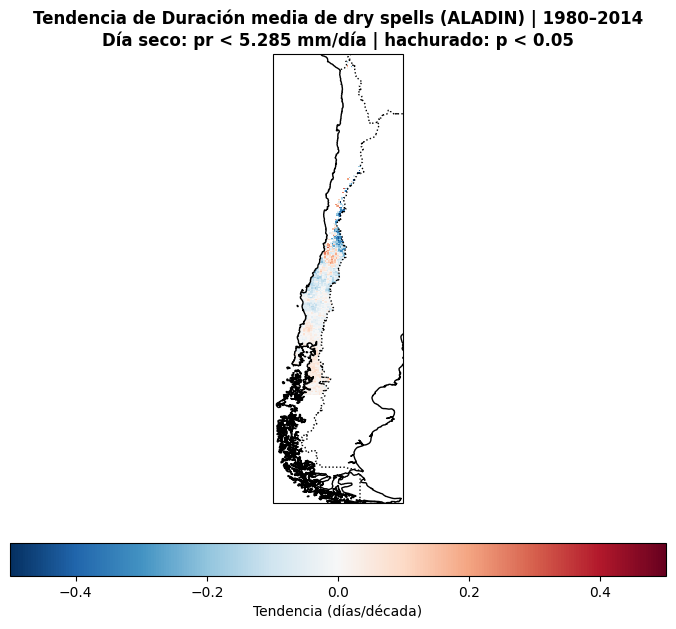

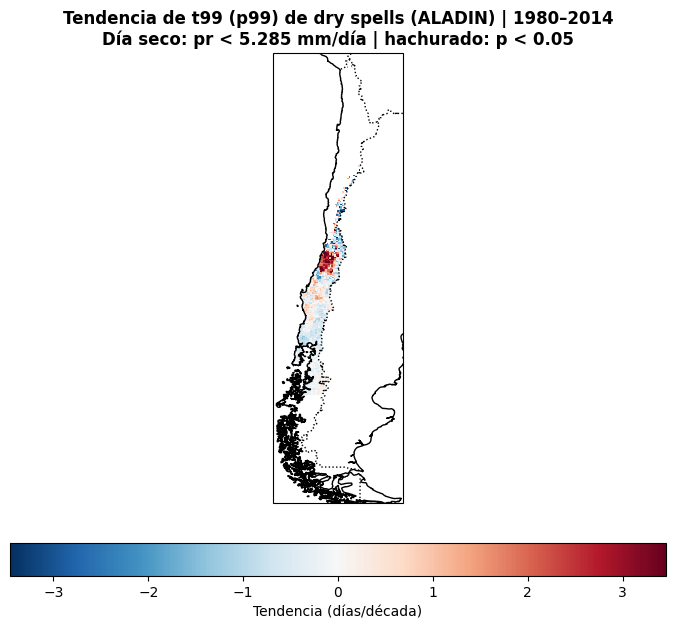

,metric,mean_slope,median_slope,% positive,% significant,% positive & significant
0,Duración media,-0.027,-0.009,4.446,0.035,0.000
1,t99 (p99),0.001,-0.163,3.749,0.115,0.012


In [16]:
# =====================================================================
# MAPAS CON SIGNIFICANCIA (hachurado p < alpha)
# =====================================================================
def summarize_map(slope_da, p_da, metric_label):
    data = slope_da.where(chile_mask).values
    pvals = p_da.where(chile_mask).values
    return pd.Series({
        'metric': metric_label,
        'mean_slope': float(np.nanmean(data)),
        'median_slope': float(np.nanmedian(data)),
        '% positive': float(np.nanmean(data > 0) * 100.0),
        '% significant': float(np.nanmean(pvals < ALPHA) * 100.0),
        '% positive & significant': float(np.nanmean((data > 0) & (pvals < ALPHA)) * 100.0),
    })


def plot_trend_map(slope_da, p_da, title):
    vals = slope_da.where(chile_mask).values.ravel()
    vals = vals[np.isfinite(vals)]
    lim = float(np.nanpercentile(np.abs(vals), 98)) if vals.size else 1.0
    lim = max(lim, 0.5)

    fig, ax = plt.subplots(1, 1, figsize=(8.5, 6.5), subplot_kw={'projection': ccrs.PlateCarree()})
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    ax.set_extent(CHILE_EXTENT)

    im = slope_da.plot.pcolormesh(
        ax=ax, x='lon', y='lat', transform=ccrs.PlateCarree(),
        cmap='RdBu_r', vmin=-lim, vmax=lim, add_colorbar=False,
    )

    sig_mask = xr.where(p_da < ALPHA, 1.0, np.nan)
    ax.contourf(
        slope_da['lon'], slope_da['lat'], sig_mask,
        levels=[0.5, 1.5], colors='none', hatches=['....'], transform=ccrs.PlateCarree(),
    )

    cbar = fig.colorbar(im, ax=ax, orientation='horizontal', shrink=0.8, pad=0.07)
    cbar.set_label('Tendencia (días/década)')
    ax.set_title(title, fontweight='bold')
    plt.tight_layout()
    plt.show()


print('4/4: Plot + resumen espacial...')
rows = []
labels = {
    'mean': 'Duración media',
    't99': 't99 (p99)',
}
for metric in ['mean', 't99']:
    slope_da = trend_maps[metric]
    p_da = p_maps[metric]
    plot_trend_map(
        slope_da, p_da,
        title=(
            f'Tendencia de {labels[metric]} de dry spells (ALADIN) | {years[0]}–{years[-1]}\n'
            f'Día seco: pr < {DRY_THRESHOLD_ALADIN:g} mm/día | hachurado: p < {ALPHA}'
        ),
    )
    rows.append(summarize_map(slope_da, p_da, labels[metric]))

summary_df = pd.DataFrame(rows)
display(summary_df.round(3))
